# Quantium Virtual Internship - Retail Strategy and Analyst 

# Customer Analysis

**Prepared by:** Vivian Nguyen 

**Dataset:** QVI Transaction Data and QVI Purchase Behavior 

**Objective:** Improve understanding of customer purchasing (Chip) behavior, identify high-value customer segments, uncover sales drivers, and provide actionable recomendations for targeted marketing and product strategy. 

In [96]:
# import libraries
import pandas as pd
import numpy as np   
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent plot style
plt.style.use("ggplot")

In [97]:
# Load customer dataset 
customers = pd.read_csv("QVI_purchase_behaviour.csv")

# Load transaction dataset (Excel file)
transactions = pd.read_csv("QVI_transaction_data.csv")

## Exploratory Data Analysis

### Examine Transaction Dataset 

In [98]:
# Examine the transaction data - view a summary of the table 
trans_df = transactions.copy()
trans_df 

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


The date are now is in an integer format, conver to DD/MM/YYYY format 

In [ ]:
# Convert numeric YYYYMMDD to proper datetime
transactions['DATE'] = pd.to_datetime(
    transactions['DATE'], 
    unit='D', 
    origin='1899-12-30'
)

In [92]:
# Check format of replacement date column
print(transactions['DATE'].dtype)
print(transactions['DATE'].head())

datetime64[ns]
0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: DATE, dtype: datetime64[ns]


In [100]:
trans_df=transactions.copy() #update the database 

Ensure that only chip purchases are examined 

In [101]:
# View all unique entries in the product name column 
trans_df['PROD_NAME'].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime 150g',
       'Twisties Cheese     270g', 'WW Crinkle Cut      Chicken 175g',
       'Thins Chips Light&  Tangy 175g', 'CCs Original 175g',
       'Burger Rings 220g', 'NCC Sour Cream &    Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle      Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt     And Vinegar 175g',
       'Smiths Chip Thinly  Cut Original 175g', 'K

To verify that the dataset contains only chip purchases by cleaning the product names, removing digits and symbols, and analysing word frequencies to identify any non-chip items.

In [102]:
# Remove digits from the product names
prod_name = trans_df['PROD_NAME'].str.replace(r'[0-9]+[gG]','');
# Remove & characters from the product names and replace with a space to separate flavours
prod_name = prod_name.str.replace(r'&',' ');

In [103]:
# Count the frequencies of words in product names and display counts in descending order
word_counts = pd.Series(' '.join(prod_name).split()).value_counts()

with pd.option_context('display.max_rows', None): # show all rows
  display(word_counts)

175g                  60561
Chips                 49770
150g                  41633
Kettle                41288
Smiths                28860
Salt                  27976
Cheese                27890
Pringles              25102
134g                  25102
Doritos               24962
Crinkle               23960
110g                  22387
Corn                  22063
Original              21560
Cut                   20754
Chip                  18645
170g                  18502
Salsa                 18094
Chicken               15407
Chilli                15390
165g                  15297
Sea                   14145
Thins                 14075
Sour                  13882
Crisps                12607
330g                  12540
Vinegar               12402
300g                  12041
RRD                   11894
Sweet                 11060
Infuzions             11057
Supreme               10963
Chives                10951
Cream                 10723
WW                    10320
Popd                

There are some entries are salsas, our goald is analysing the chip purchases only. The salsas purchased will be removed.

In [104]:
# Remove salsas from the dataset
trans_df = trans_df[trans_df['PROD_NAME'].str.contains(r"[Ss]alsa") == False]
trans_df.shape # check for a reduction in no of rows 

(246742, 8)

Summarise the data information (min, max, mean) to test if there are any outliers in the dataset and if there are any nulls in any collumn. 

In [105]:
# Transaaction data summary statistics
trans_df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


In [106]:
# Check if there are any nulls in the dataset
trans_df.isnull().values.any()

False

From the summary we can see the max prod_qty is 200 that means there is at least one transaction with 200 packets. 

In [107]:
# Filter the entries that have 200 packets. 
trans_df.loc[trans_df['PROD_QTY'] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


The same customer had made these transactions. They could be for commercial purposes, check to see if they made any other purchases. 

In [108]:
# Filter the transactions made by this customer
trans_df.loc[trans_df['LYLTY_CARD_NBR'] == 226000]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


They has made only these above transactions. Remove these outliers from the dataset

In [109]:
# Remove the outlier transactions 
trans_df = trans_df[trans_df['LYLTY_CARD_NBR'] != 226000]
trans_df.shape # check for a reduction in no of rows

(246740, 8)

In [110]:
# Recheck the data summary 
trans_df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000
mean,2018-12-30 01:18:58.448569344,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897


Now checking the date to see if there are any missing data from particular days

In [112]:
# Count transactions by date to see if there are any missing days 
count = trans_df.groupby(trans_df['DATE'].dt.date).size().reset_index(name='COUNT')
count.shape

(364, 2)

In [113]:
# There is one day of data missing. Check the range of dates by sorting in time order 
trans_df.sort_values(by='DATE')

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
9161,2018-07-01,88,88140,86914,25,Pringles SourCream Onion 134g,2,7.4
155442,2018-07-01,60,60276,57330,3,Kettle Sensations Camembert & Fig 150g,2,9.2
181349,2018-07-01,199,199014,197623,104,Infuzions Thai SweetChili PotatoMix 110g,2,7.6
229948,2018-07-01,35,35052,31630,11,RRD Pc Sea Salt 165g,1,3.0
104647,2018-07-01,72,72104,71038,20,Doritos Cheese Supreme 330g,2,11.4
...,...,...,...,...,...,...,...,...
10254,2019-06-30,112,112141,114611,98,NCC Sour Cream & Garden Chives 175g,2,6.0
113220,2019-06-30,207,207155,205513,99,Pringles Sthrn FriedChicken 134g,2,7.4
229182,2019-06-30,10,10140,9882,12,Natural Chip Co Tmato Hrb&Spce 175g,2,6.0
229015,2019-06-30,6,6258,6047,29,French Fries Potato Chips 175g,1,3.0


Date shows the transaction from 01 July 2018 to 30 Jun 2019. Check through the year of dates to see which day has the missing data

In [114]:
# Generate a list of dates with transactions in ascending order 
date_counts = trans_df.groupby('DATE').size()

In [115]:
# Compare full list of dates within the same range to find differences between them 
pd.date_range(start='2018-07-01', end='2019-06-30').difference(date_counts.index)

DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')

The missing date is 2018 Christmas day. As this is public holdiay, it is expected there is no sale on that day. 

Creating other features such as the pack size and checking this for any outliers. 

In [117]:
# Add a new column to data with packet sizes and extract sizes from product name column
trans_df.insert(8, "PACK_SIZE", trans_df['PROD_NAME'].str.extract('(\d+)').astype(float), True)

In [118]:
# Sort by packet sizes to check for outliers 
trans_df.sort_values(by='PACK_SIZE')

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE
40783,2018-09-25,97,97067,96696,38,Infuzions Mango Chutny Papadums 70g,2,4.8,70.0
42461,2019-05-05,110,110030,111890,38,Infuzions Mango Chutny Papadums 70g,2,4.8,70.0
176183,2018-12-30,82,82183,81660,38,Infuzions Mango Chutny Papadums 70g,2,4.8,70.0
227309,2018-12-03,236,236091,239098,38,Infuzions Mango Chutny Papadums 70g,2,4.8,70.0
42418,2018-11-05,109,109217,111470,38,Infuzions Mango Chutny Papadums 70g,2,4.8,70.0
...,...,...,...,...,...,...,...,...,...
192034,2019-03-12,100,100121,99145,4,Dorito Corn Chp Supreme 380g,2,13.0,380.0
255797,2019-01-19,235,235098,238018,4,Dorito Corn Chp Supreme 380g,2,13.0,380.0
233814,2019-01-24,151,151102,149810,4,Dorito Corn Chp Supreme 380g,1,6.5,380.0
131573,2018-07-09,213,213087,212416,4,Dorito Corn Chp Supreme 380g,2,13.0,380.0


Minimum packet size is 70g and max is 380g.

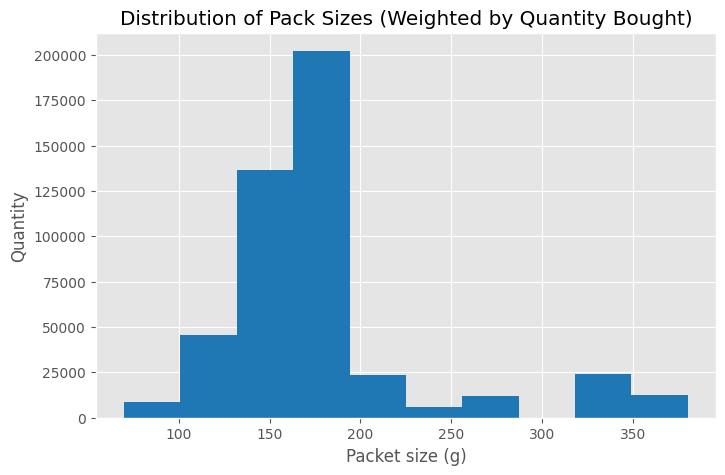

In [140]:
# Plot a histogram to visualise distribution of pack sizes. 

plt.figure(figsize=(8,5))

plt.hist(
    trans_df['PACK_SIZE'],
    weights=trans_df['PROD_QTY'],
    color=plt.cm.tab20(0)   # SAME colour tone as your previous chart
)

plt.xlabel('Packet size (g)')
plt.ylabel('Quantity')
plt.title('Distribution of Pack Sizes (Weighted by Quantity Bought)')

plt.show()

- Most chips sold are in the 150–200g range (standard share bags).
- Small packs (<120g) represent a minor share of total sales.
- Large family-size packs (300g+) appear in low volumes.
- No unusual or invalid pack sizes detected — data quality looks consistent and reliable.

Extract brand names using the first word of each product name 

In [120]:
# Add a column to extract the first word of each product name to. 
trans_df.insert(9, "BRAND_NAME",trans_df['PROD_NAME'].str.split().str.get(0), True)
trans_df

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle
...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175.0,Kettle
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175.0,Tostitos
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170.0,Doritos
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150.0,Doritos


In [121]:
# Summarise the brand names
trans_df["BRAND_NAME"].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Grain', 'Doritos',
       'Twisties', 'WW', 'Thins', 'Burger', 'NCC', 'Cheezels', 'Infzns',
       'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith', 'GrnWves',
       'Tyrrells', 'Cobs', 'French', 'RRD', 'Tostitos', 'Cheetos',
       'Woolworths', 'Snbts', 'Sunbites'], dtype=object)

There are some names have been doubled. Replace all contractions and double ups with their full name 

In [122]:
# Create a function to identify the string replacements needed.
def replace_brandname(line):
    name = line['BRAND_NAME']
    if name == "Infzns":
        return "Infuzions"
    elif name == "Red":
        return "Red Rock Deli"
    elif name == "RRD":
        return "Red Rock Deli"
    elif name == "Grain":
        return "Grain Waves"
    elif name == "GrnWves":
        return "Grain Waves"
    elif name == "Snbts":
        return "Sunbites"
    elif name == "Natural":
        return "Natural Chip Co"
    elif name == "NCC":
        return "Natural Chip Co"
    elif name == "WW":
        return "Woolworths"
    elif name == "Smith":
        return "Smiths"
    elif name == "Dorito":
        return "Doritos"
    else:
        return name 

# Apply the function to clean the brand names
trans_df["BRAND_NAME"] = trans_df.apply(lambda line: replace_brandname(line), axis=1)

# Check that there are no duplicate brands 
trans_df["BRAND_NAME"].unique()

array(['Natural Chip Co', 'CCs', 'Smiths', 'Kettle', 'Grain Waves',
       'Doritos', 'Twisties', 'Woolworths', 'Thins', 'Burger', 'Cheezels',
       'Infuzions', 'Red Rock Deli', 'Pringles', 'Tyrrells', 'Cobs',
       'French', 'Tostitos', 'Cheetos', 'Sunbites'], dtype=object)

cust_df = customerdata.copy()
cust_df.head()

In [125]:
cust_df = customers.copy()
cust_df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [126]:
# Rename "PREMIUM_CUSTOMER" to "MEMBER_TYPE" for easier identification of the column data
cust_df = cust_df.rename(columns={'PREMIUM_CUSTOMER': 'MEMBER_TYPE'})

In [127]:
# Check summary of the customer dataset 
cust_df.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [ ]:
# Check the entries in the number type and lifestage columns 
cust_df['NUMBER_TYPE'].unique()

In [129]:
cust_df["LIFESTAGE"].unique()

array(['YOUNG SINGLES/COUPLES', 'YOUNG FAMILIES', 'OLDER SINGLES/COUPLES',
       'MIDAGE SINGLES/COUPLES', 'NEW FAMILIES', 'OLDER FAMILIES',
       'RETIREES'], dtype=object)

Merge the customer dataset to the transaction dataset 

In [130]:
# Join the customer and transaction datasets, and sort transactons by date 
full_df = trans_df.set_index('LYLTY_CARD_NBR').join(cust_df.set_index('LYLTY_CARD_NBR'))
full_df = full_df.reset_index()
full_df = full_df.sort_values(by='DATE').reset_index(drop=True)
full_df

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND_NAME,LIFESTAGE,MEMBER_TYPE
0,88140,2018-07-01,88,86914,25,Pringles SourCream Onion 134g,2,7.4,134.0,Pringles,MIDAGE SINGLES/COUPLES,Mainstream
1,60276,2018-07-01,60,57330,3,Kettle Sensations Camembert & Fig 150g,2,9.2,150.0,Kettle,RETIREES,Mainstream
2,199014,2018-07-01,199,197623,104,Infuzions Thai SweetChili PotatoMix 110g,2,7.6,110.0,Infuzions,RETIREES,Premium
3,35052,2018-07-01,35,31630,11,RRD Pc Sea Salt 165g,1,3.0,165.0,Red Rock Deli,YOUNG SINGLES/COUPLES,Budget
4,72104,2018-07-01,72,71038,20,Doritos Cheese Supreme 330g,2,11.4,330.0,Doritos,OLDER SINGLES/COUPLES,Mainstream
...,...,...,...,...,...,...,...,...,...,...,...,...
246735,112141,2019-06-30,112,114611,98,NCC Sour Cream & Garden Chives 175g,2,6.0,175.0,Natural Chip Co,MIDAGE SINGLES/COUPLES,Mainstream
246736,207155,2019-06-30,207,205513,99,Pringles Sthrn FriedChicken 134g,2,7.4,134.0,Pringles,OLDER SINGLES/COUPLES,Mainstream
246737,10140,2019-06-30,10,9882,12,Natural Chip Co Tmato Hrb&Spce 175g,2,6.0,175.0,Natural Chip Co,YOUNG SINGLES/COUPLES,Budget
246738,6258,2019-06-30,6,6047,29,French Fries Potato Chips 175g,1,3.0,175.0,French,YOUNG SINGLES/COUPLES,Budget


In [131]:
# Check for nulls in the full dataset 
full_df.isnull().values.any()

False

In [132]:
# Export the cleaned full dataset to a CSV file
full_df.to_csv('QVI_fulldata.csv')

## Data Analysis on Customer Segments 

Now that the dataset has been fully cleaned and filtered to include only chip purchases, we can begin analysing customer behaviour to uncover meaningful insights that will guide our business strategy.

To understand which customer groups drive chip sales, we will evaluate several key metrics:
- Total chip sales by customer segment, segmented by both LIFESTAGE and PREMIUM_CUSTOMER status
- Number of customers in each segment
- Total quantity of chips purchased per customer across the analysis period
- Average chip price per customer segment, helping us understand premium vs value-focused behaviours

In addition to the chip dataset, there are several complementary data points that would further enrich the analysis if provided by the wider data team:
- A customer’s total grocery spend for the year, and their spend per transaction, to determine what proportion of their shopping budget is allocated to chips
- Spending patterns on other snack categories (e.g., crackers, biscuits), which would allow us to compare chip purchasing frequency and identify cross-category preferences
- The overall distribution of customer segments across the entire shopper base, enabling comparison against the segment mix of chip purchasers specifically

With the cleaned data prepared, the first step is to explore the distribution of total chip sales across the different `LIFESTAGE` and `MEMBER_TYPE` groups. This allows us to identify which customer types contribute the most to chip revenue and highlights priority segments for further investigation.

In [135]:
# Total Sales by Customer Segment 
sales_by_segment = (
    full_df.groupby(['LIFESTAGE', 'MEMBER_TYPE'])['TOT_SALES']
    .sum()
    .reset_index()
    .sort_values(by='TOT_SALES', ascending=False)
)

# Display the segment sales table
display(sales_by_segment)

,LIFESTAGE,MEMBER_TYPE,TOT_SALES
6,OLDER FAMILIES,Budget,156863.75
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20
13,RETIREES,Mainstream,145168.95
15,YOUNG FAMILIES,Budget,129717.95
9,OLDER SINGLES/COUPLES,Budget,127833.60
10,OLDER SINGLES/COUPLES,Mainstream,124648.50
11,OLDER SINGLES/COUPLES,Premium,123537.55
12,RETIREES,Budget,105916.30
7,OLDER FAMILIES,Mainstream,96413.55
14,RETIREES,Premium,91296.65


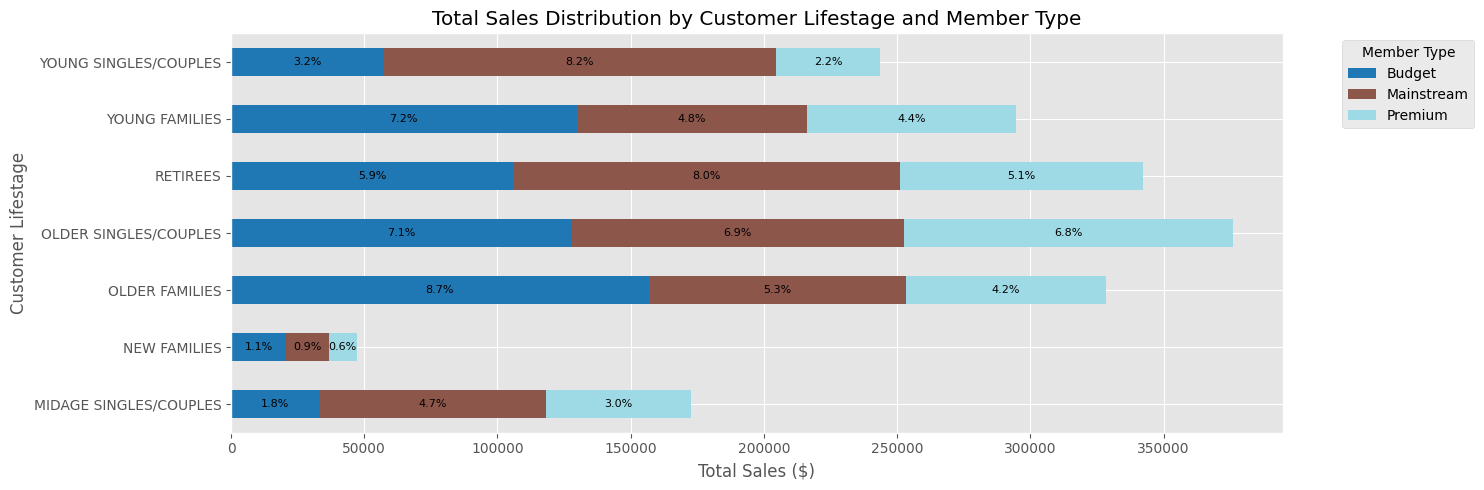

In [ ]:
# Visualise of Sales by Customer Segment

import matplotlib.pyplot as plt

# Compute total sales for later percentage calculations
total_sales = full_df['TOT_SALES'].sum()

# Group data by Lifestage + Member Type
total_sales_breakdown = (
    full_df
    .groupby(['LIFESTAGE','MEMBER_TYPE'])['TOT_SALES']
    .agg(['sum', 'mean'])
    .unstack('MEMBER_TYPE')              # Create side-by-side bars
    .fillna(0)                           # Fill empty combinations with 0
)

# Plot the stacked horizontal bar chart
ax = total_sales_breakdown['sum'].plot(
    kind='barh',
    stacked=True,
    figsize=(15, 5),
    colormap='tab20'
)

# Label each bar with its % of total sales 

for rect in ax.patches:
    height = rect.get_height()
    width = rect.get_width()           # total sales for that segment+type
    x = rect.get_x()
    y = rect.get_y()

    if width > 0:
        pct = width / total_sales * 100
        label = f"{pct:.1f}%"

        # Center the label inside each coloured bar
        label_x = x + width / 2
        label_y = y + height / 2

        ax.text(label_x, label_y, label, ha='center', va='center', fontsize=8)

# Chart formatting 
ax.set_xlabel("Total Sales ($)")
ax.set_ylabel("Customer Lifestage")
ax.set_title("Total Sales Distribution by Customer Lifestage and Member Type")
ax.legend(title="Member Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


### Key Insights: Total Sales by Lifestage & Member Type

- **Mainstream and Budget shoppers drive most chip sales**, showing strong demand from value-focused households.
- **Older Families and Older Singles/Couples are the highest-value segments**, contributing the largest share of revenue.
- **Young Families and Young Singles/Couples show solid mid-level sales**, mainly from Mainstream and Budget members — strong potential for growth.
- **Premium customers contribute a smaller but higher-value share**, especially in Midage and Older Singles segments, favouring premium brands.
- **New Families contribute the least** and are not a priority target segment.

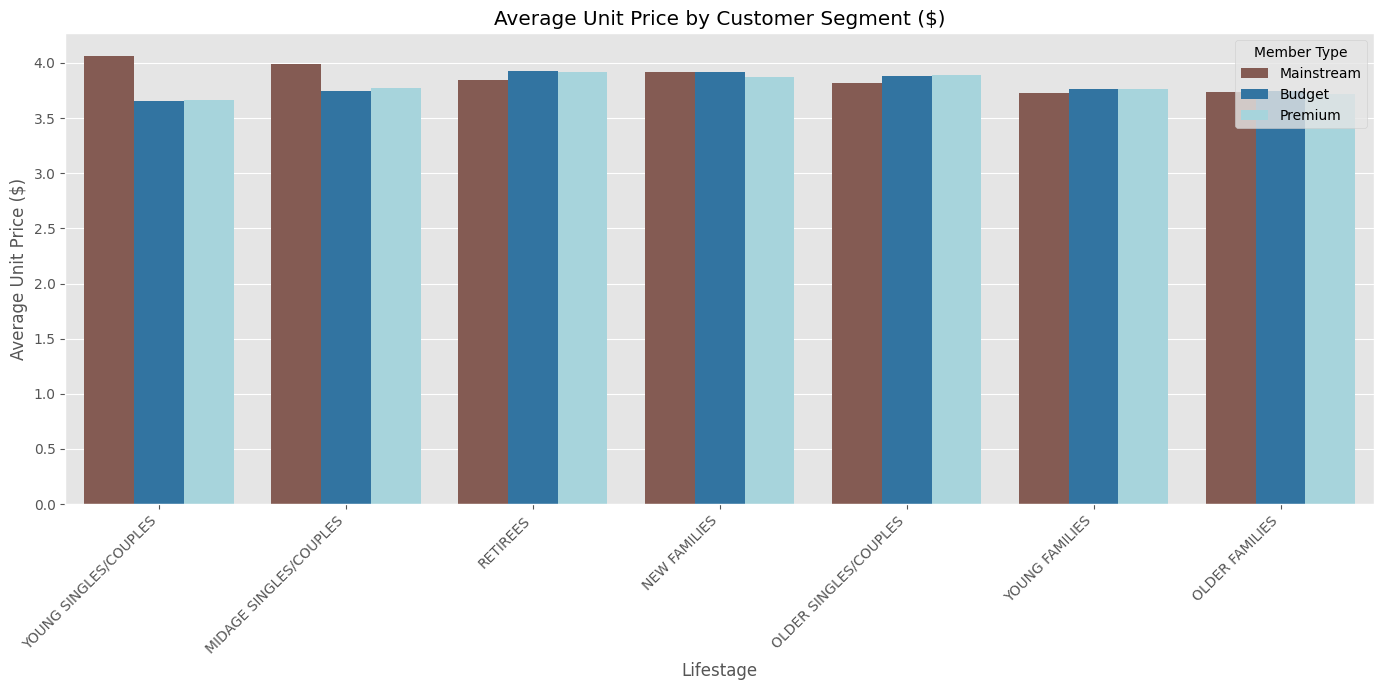

In [ ]:
# Average Unit Price & Quantity by Customer Segment
full_df['UNIT_PRICE'] = full_df['TOT_SALES'] / full_df['PROD_QTY']

avg_price_by_segment = (
    full_df.groupby(['LIFESTAGE', 'MEMBER_TYPE'])['UNIT_PRICE']
    .mean()
    .reset_index(name='AVG_UNIT_PRICE')
    .sort_values(by='AVG_UNIT_PRICE', ascending=False)
)


member_colors = {
    'Budget': plt.cm.tab20(0),
    'Mainstream': plt.cm.tab20(10),
    'Premium': plt.cm.tab20(19)
}

plt.figure(figsize=(14,7))

sns.barplot(
    data=avg_price_by_segment,
    x='LIFESTAGE',
    y='AVG_UNIT_PRICE',
    hue='MEMBER_TYPE',
    palette=member_colors
)

plt.title("Average Unit Price by Customer Segment ($)")
plt.xlabel("Lifestage")
plt.ylabel("Average Unit Price ($)")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Member Type')
plt.tight_layout()
plt.show()

- For **Young** and **Midage Singles/Couples**, *Mainstream* shoppers pay slightly more per unit than *Budget* and *Premium* groups.  
- Despite the higher unit price, these segments show **lower total sales and fewer chip buyers**, suggesting chips may not be their preferred snack choice.
- Additional data on **overall snack spending and shopping habits** would help confirm whether these customers substitute chips with other snack categories.
- Since the price differences are small, a **t-test** is recommended to determine whether the variation in average unit price is statistically significant.

In [161]:
# T-Test: Young & Midage Singles/Couples (Mainstream vs Budget/Premium)

from scipy.stats import ttest_ind

# Define segment filters
is_mainstream = full_df["MEMBER_TYPE"] == "Mainstream"
is_young_mid = full_df["LIFESTAGE"].isin(["MIDAGE SINGLES/COUPLES", "YOUNG SINGLES/COUPLES"])
is_non_mainstream = full_df["MEMBER_TYPE"] != "Mainstream"

# Extract unit prices for each comparison group
group_mainstream = full_df[is_mainstream & is_young_mid]["UNIT_PRICE"]
group_other = full_df[is_non_mainstream & is_young_mid]["UNIT_PRICE"]

# Perform Welch's t-test (unequal variances recommended)
t_stat, p_val = ttest_ind(group_mainstream, group_other, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 37.6243885962295
P-value: 6.967354233018139e-306


The t-test shows an extremely small p-value (**6.97e-306**), which is far below the 0.05 significance threshold. 

This means the difference in average unit price between **Mainstream** and **non-Mainstream** Young/Midage Singles & Couples is **statistically significant**, not due to random chance. 

In other words, these Mainstream shoppers genuinely pay more per unit than their Budget or Premium counterparts within the same lifestage group.






### Deep dive into specific customer segments for insights

From our earlier analysis, *Mainstream Young Singles/Couples* emerged as an interesting customer segment:  
they pay slightly more per unit than other customer types, yet their total chip spend is relatively low.  
To understand their behaviour better, we now investigate whether they show a **distinct preference for certain chip brands**.

This insight can help determine:
- Whether their low total spend is due to **brand loyalty**,  
- Whether they prefer **premium-positioned brands**, or  
- Whether chips simply aren’t a preferred snack for this demographic.

In [165]:
# Filter the target customer segment
target_segment = full_df[
    (full_df['MEMBER_TYPE'] == 'Mainstream') &
    (full_df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES')
]

# Calculate total sales by brand for this segment
# -------------------------------------------------------------
# Aggregates chip sales for each brand, sorted greatest → least
brand_sales = (
    target_segment.groupby('BRAND_NAME')['TOT_SALES']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Display top brands purchased by this segment
brand_sales.head()

,BRAND_NAME,TOT_SALES
0,Kettle,35423.6
1,Doritos,20925.9
2,Pringles,16006.2
3,Smiths,14958.9
4,Infuzions,8749.4


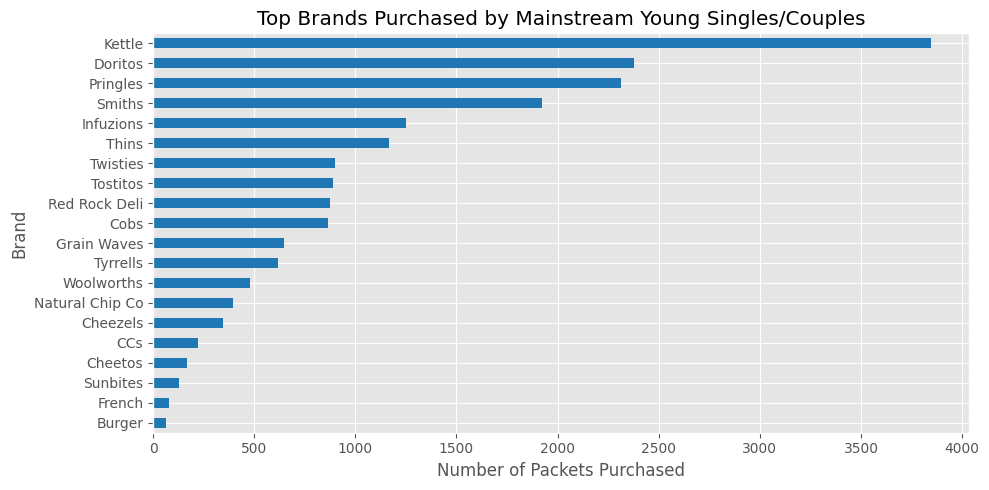

In [175]:
# Visualise of what brands young singles/couples are purchasing the most for a general indication
young_mainstream = full_df[
    (full_df['LIFESTAGE'] == "YOUNG SINGLES/COUPLES") &
    (full_df['MEMBER_TYPE'] == "Mainstream")
]

plt.figure(figsize=(10,5))

ax = (
    young_mainstream["BRAND_NAME"]
    .value_counts()
    .sort_values(ascending=True)
    .plot.barh(color=plt.cm.tab20(0))   # blue from tab20 palette
)

ax.set_xlabel("Number of Packets Purchased")
ax.set_ylabel("Brand")
ax.set_title("Top Brands Purchased by Mainstream Young Singles/Couples")

plt.tight_layout()
plt.show()

- **Kettle dominates this segment**, with significantly higher purchase volume than any other brand. This indicates a strong preference for premium-style, higher-quality chips within this group.  
- **Doritos, Pringles, and Smiths** also perform strongly, suggesting that mainstream young singles/couples prefer well-known, widely marketed national brands.  
- Mid-tier brands like **Infuzions, Thins, Twisties, and Red Rock Deli** show moderate engagement, while **supermarket/private-label brands** (e.g., Woolworths, Natural Chip Co.) appear less popular.  
- Niche or lower-presence brands such as **Sunbites, French Fries, and Burger Rings** have minimal share, indicating minimal affinity within this target group.

**Overall, this segment leans toward bold-flavoured, well-marketed branded chips, particularly Kettle and Doritos—signaling strong opportunities for premium flavour innovation and brand-led promotions.**

In [178]:
# Target segment brand proportion
target_segment = full_df[
    (full_df['MEMBER_TYPE'] == 'Mainstream') &
    (full_df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES')
]

target_brand_prop = (
    target_segment.groupby("BRAND_NAME")["PROD_QTY"].sum()
    / target_segment["PROD_QTY"].sum()
)

# Other customers brand proportion
other_customers = full_df[
    ~(
        (full_df['MEMBER_TYPE'] == 'Mainstream') &
        (full_df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES')
    )
]

other_brand_prop = (
    other_customers.groupby("BRAND_NAME")["PROD_QTY"].sum()
    / other_customers["PROD_QTY"].sum()
)

# Combine into a table
brand_affinity = pd.DataFrame({
    "target": target_brand_prop,
    "other": other_brand_prop
}).fillna(0)

# Calculate affinity index
brand_affinity["affinity"] = brand_affinity["target"] / brand_affinity["other"]

# Sort highest → lowest
brand_affinity_sorted = brand_affinity.sort_values("affinity", ascending=False)
brand_affinity_sorted.head(10)

,target,other,affinity
BRAND_NAME,,,
Tyrrells,0.031553,0.025692,1.228095
Twisties,0.046184,0.037877,1.219319
Doritos,0.122761,0.101075,1.214553
Kettle,0.197985,0.165553,1.195897
Tostitos,0.045411,0.037978,1.195713
Pringles,0.119420,0.100635,1.186670
Cobs,0.044638,0.039049,1.143124
Infuzions,0.064679,0.057065,1.133435
Thins,0.060373,0.056986,1.059423


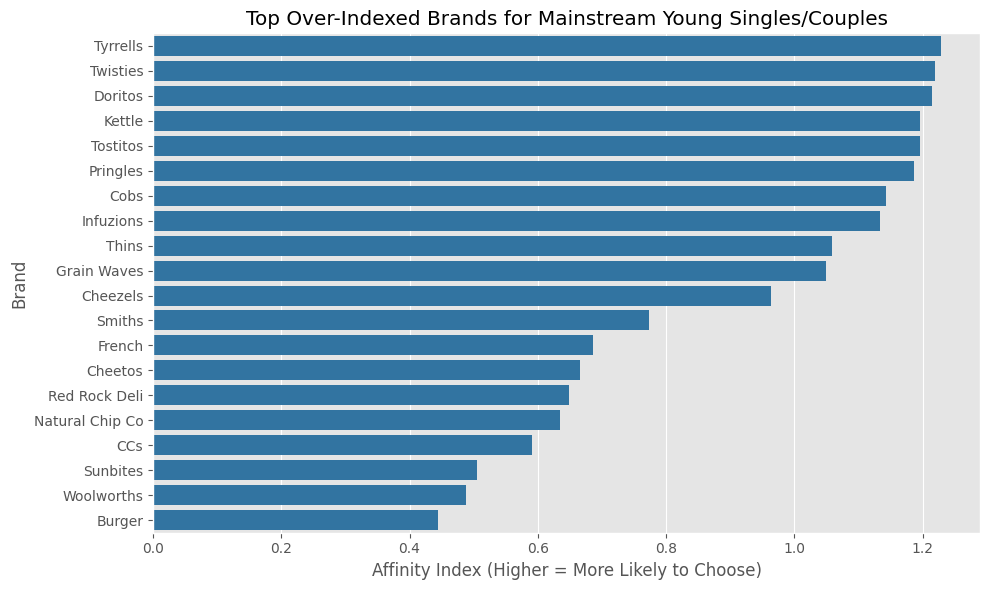

In [187]:
plt.figure(figsize=(10,6))

top_affinity = brand_affinity_sorted.head(100)

sns.barplot(
    data=top_affinity.reset_index(),
    x="affinity",
    y="BRAND_NAME",
    color=plt.cm.tab20(0)  # brown from your palette
)

plt.title("Top Over-Indexed Brands for Mainstream Young Singles/Couples")
plt.xlabel("Affinity Index (Higher = More Likely to Choose)")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()


- **Tyrrells, Twisties, Doritos, and Kettle** show the strongest affinity (≈1.20–1.28), meaning this segment is **20–28% more likely** to buy these brands than the rest of the customer base.  
- Other brands such as **Pringles, Cobs, Infuzions, and Thins** also index above average, indicating a preference for **premium, flavour-driven, and snack-style chips**.  
- Lower-affinity brands like **Woolworths, Sunbites, and Burger Rings** suggest weaker relevance for this demographic.

→ Focus marketing and promotional efforts on **Tyrrells, Twisties, Doritos, and Kettle**, as these brands resonate most with mainstream young singles/couples and represent the highest potential for targeted growth.

In [183]:
# Average pack size for target segment vs other customers
target_pack_avg = target_segment["PACK_SIZE"].mean()
other_pack_avg = other_customers["PACK_SIZE"].mean()

print("Average Pack Size - Target Segment:", target_pack_avg)
print("Average Pack Size - Other Customers:", other_pack_avg)


Average Pack Size - Target Segment: 178.34424887433482
Average Pack Size - Other Customers: 175.34603602176094


In [188]:

target_pack_share = (
    target_segment["PACK_SIZE"].value_counts(normalize=True)
)

other_pack_share = (
    other_customers["PACK_SIZE"].value_counts(normalize=True)
)

pack_affinity = pd.DataFrame({
    "target": target_pack_share,
    "other": other_pack_share
}).fillna(0)

pack_affinity["affinity"] = pack_affinity["target"] / pack_affinity["other"]
pack_affinity_sorted = pack_affinity.sort_values("affinity", ascending=False)
pack_affinity_sorted.head(100)

,target,other,affinity
PACK_SIZE,,,
270.0,0.031723,0.024934,1.272269
380.0,0.032030,0.025485,1.256849
330.0,0.061144,0.049935,1.224477
134.0,0.118451,0.100297,1.181003
210.0,0.029472,0.025071,1.175546
110.0,0.104943,0.089509,1.172431
135.0,0.014838,0.013059,1.136234
250.0,0.014327,0.012716,1.126673
170.0,0.080587,0.081023,0.994629


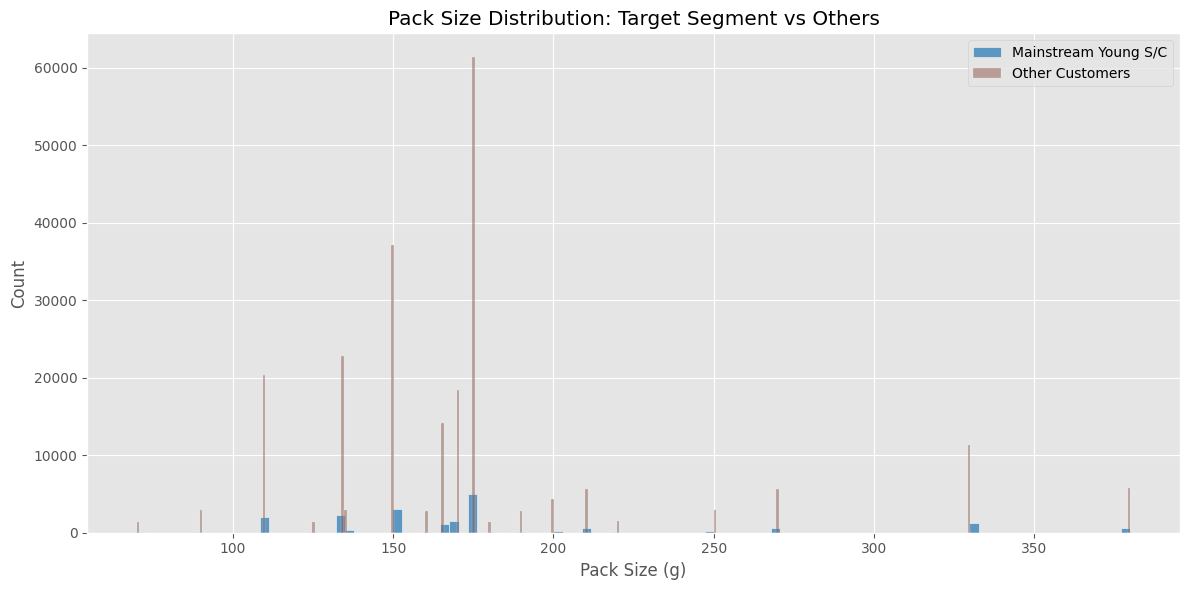

In [186]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=target_segment,
    x="PACK_SIZE",
    color=plt.cm.tab20(0),   # blue for target segment
    kde=False,
    label="Mainstream Young S/C",
    alpha=0.7
)

sns.histplot(
    data=other_customers,
    x="PACK_SIZE",
    color=plt.cm.tab20(10),   # teal for others
    kde=False,
    label="Other Customers",
    alpha=0.5
)

plt.title("Pack Size Distribution: Target Segment vs Others")
plt.xlabel("Pack Size (g)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


- **Average pack size preference is slightly higher** for the target segment  
  - Target: **178g**  
  - Others: **175g**  
  → Indicates a small uplift, suggesting mainstream young singles/couples lean **slightly more toward larger packs**, likely due to convenience or shared consumption.

- **Affinity analysis reveals meaningful pack-size preferences**  
  - The segment is **27% more likely** to buy **270g** packs  
  - **380g** and **330g** packs also index higher  
  → These over-indexed sizes suggest that when this group buys chips, they **prefer larger or “value-sized” packs** compared to other customers.

- **Visual distribution confirms stronger representation in larger pack sizes**  
  - Although the segment is smaller (fewer customers), the chart shows consistent uptake in **150g–200g+ ranges** compared to baseline shoppers.  
  → Supports the insight that this group treats chips as an occasional but larger-portion purchase.

---
## Summary of Insights
The chip category is driven by a mix of population size and segment-level purchasing behaviours. Mainstream Young Singles/Couples emerge as an influential and high-value customer group, showing strong preferences for premium brands and larger pack sizes. By optimising product placement, enhancing promotional targeting, and leveraging brand affinity data, the business can strengthen category performance and capture further value across key customer

### Key Sales-Contributing Segments
- The highest contributors to total chip sales are:
  - **Older Families – Budget**
  - **Young Singles/Couples – Mainstream**
  - **Retirees – Mainstream**
- For the mainstream groups, total sales are largely driven by their **larger customer populations**.
- For Budget Older Families, higher sales come from **greater chip purchasing volume per customer**, not population size.

### Customer Spend and Price Behaviour
- **Mainstream Young Singles/Couples exhibit the highest average spend per transaction on chips.**
- A t-test confirms that their average unit price is **statistically higher** than that of non-mainstream young/midage singles/couples.
- This suggests a genuine behavioural difference: the segment is **less price-sensitive** and more willing to pay for preferred brands or larger packs.

### Brand Preferences and Affinity Findings
- Mainstream Young Singles/Couples are:
  - **28% more likely to purchase Tyrrells**, compared to other customers.
  - Strong purchasers of **Kettle**, consistent with overall category trends.
  - **Significantly less likely (≈50%) to purchase Burger Rings**, aligning with their pack-size preferences.
- High-affinity brands for this segment include:
  - **Tyrrells, Twisties, Doritos, Kettle**
- Low-affinity brands include:
  - **Burger Rings, Sunbites, CCs**

### Pack Size Preferences
- The target segment prefers **slightly larger pack sizes** on average (178g vs. 175g for other customers).
- They show strong affinity for:
  - **270g**
  - **330g**
  - **380g**  
  These sizes indicate a preference for larger, value-oriented or shareable packs.
- Across all customers, **175g** remains the most commonly purchased pack size.